In [5]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import shap

from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

In [ ]:
best_rf = joblib.load('models/random_forest_final.pkl')
X_test = joblib.load('data/X_test_fe.pkl')
y_test = joblib.load('data/y_test.pkl')

print(X_test.shape)
print(y_test.value_counts(normalize=True))

(8256, 18)
pha
0    0.938469
1    0.061531
Name: proportion, dtype: float64


In [ ]:
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(y_test, y_pred, target_names=['Not Hazardous', 'Hazardous']))

               precision    recall  f1-score   support

Not Hazardous       0.98      0.94      0.96      7748
    Hazardous       0.47      0.78      0.59       508

     accuracy                           0.93      8256
    macro avg       0.73      0.86      0.78      8256
 weighted avg       0.95      0.93      0.94      8256



ROC-AUC Score: 0.9675


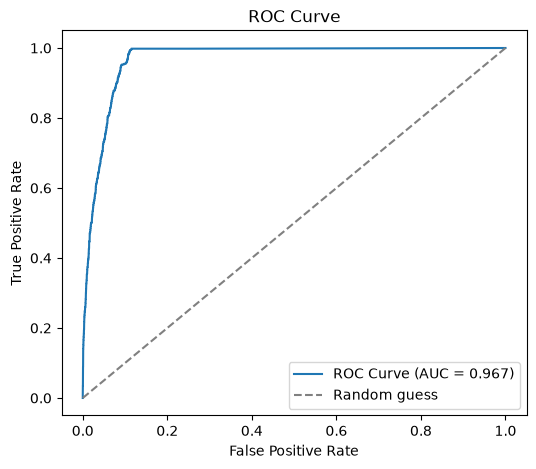

In [ ]:
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {auc_score:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('results/roc_curve.png')
plt.show()

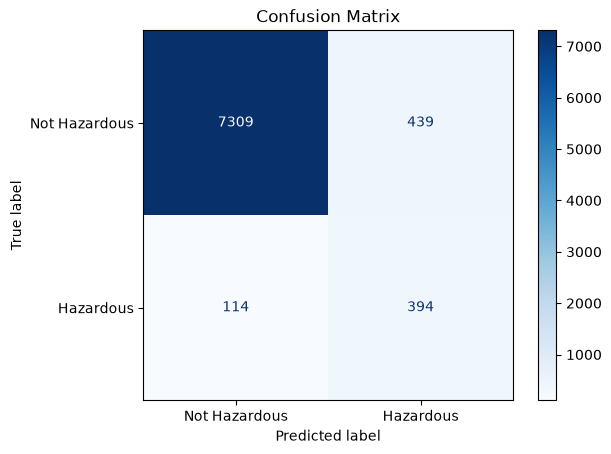

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Hazardous', 'Hazardous'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('results/confusion_matrix.png')
plt.show()

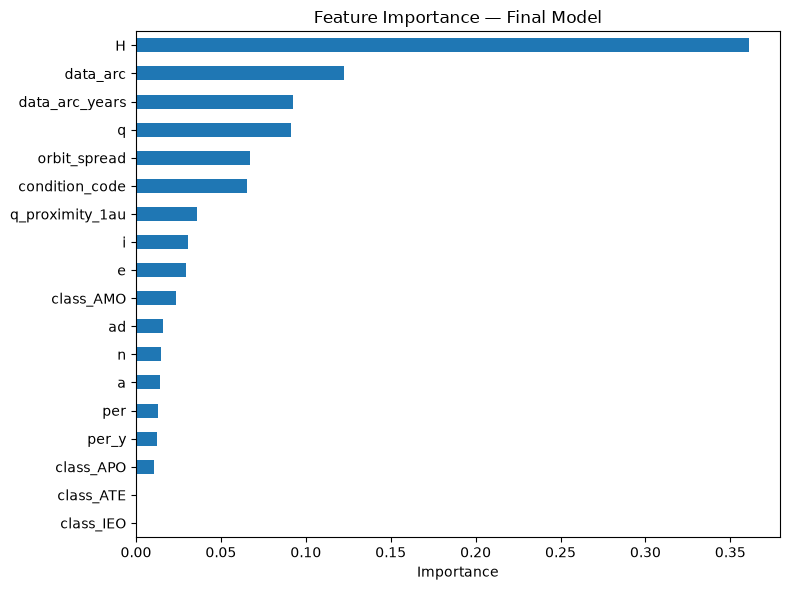

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance — Final Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('results/feature_importance.png')
plt.show()

In [ ]:
explainer = shap.TreeExplainer(best_rf)
shap_values_raw = explainer.shap_values(X_test)

print("Raw SHAP output type:", type(shap_values_raw))
print("Raw SHAP output shape:", np.array(shap_values_raw).shape)

if isinstance(shap_values_raw, list):
    # Older SHAP: list of arrays, one per class
    shap_values_hazard = shap_values_raw[1]
elif np.array(shap_values_raw).ndim == 3:
    # Newer SHAP: single array (samples, features, classes)
    shap_values_hazard = shap_values_raw[:, :, 1]
else:
    shap_values_hazard = shap_values_raw

print("Final shap_values_hazard shape:", shap_values_hazard.shape)  # should be (n_samples, n_features)

# Handle expected_value the same way
raw_base = explainer.expected_value
if isinstance(raw_base, (list, np.ndarray)) and np.array(raw_base).shape and np.array(raw_base).shape[0] > 1:
    base_value = raw_base[1]
else:
    base_value = raw_base

print("Base value:", base_value)

Raw SHAP output type: <class 'numpy.ndarray'>
Raw SHAP output shape: (8256, 18, 2)
Final shap_values_hazard shape: (8256, 18)
Base value: 0.5003691701998788


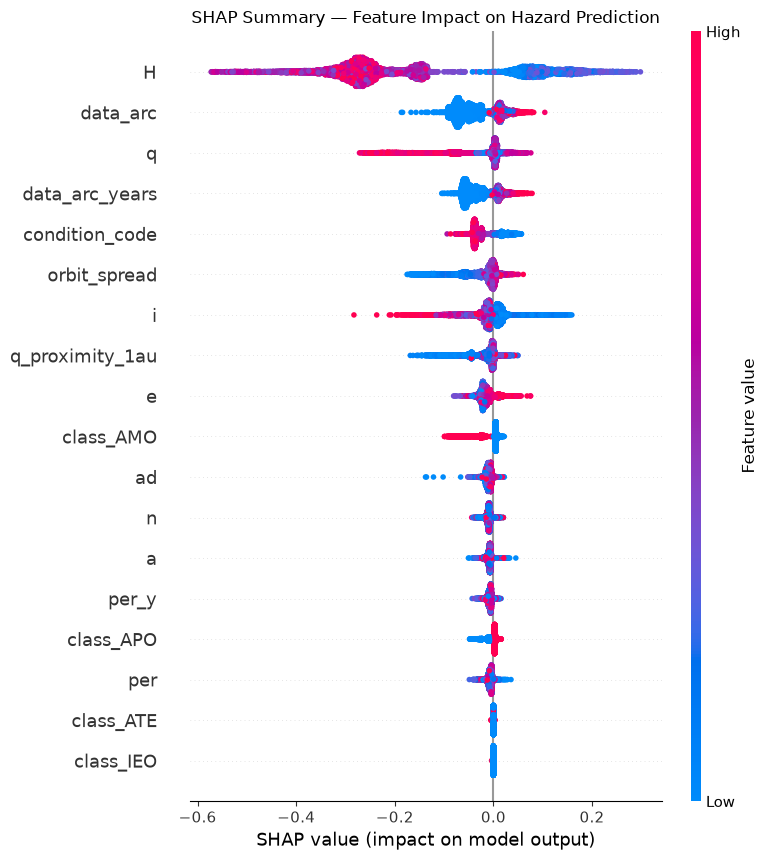

In [ ]:
shap.summary_plot(shap_values_hazard, X_test, show=False)
plt.title("SHAP Summary — Feature Impact on Hazard Prediction")
plt.tight_layout()
plt.savefig('results/shap_summary.png')
plt.show()

In [ ]:
tp_idx = np.where((y_test.values == 1) & (y_pred == 1))[0][0]
fn_idx = np.where((y_test.values == 1) & (y_pred == 0))[0][0]

print(f"True Positive row index: {tp_idx}")
print(f"False Negative row index: {fn_idx}")

True Positive row index: 14
False Negative row index: 79



--- True Positive (row 14) ---


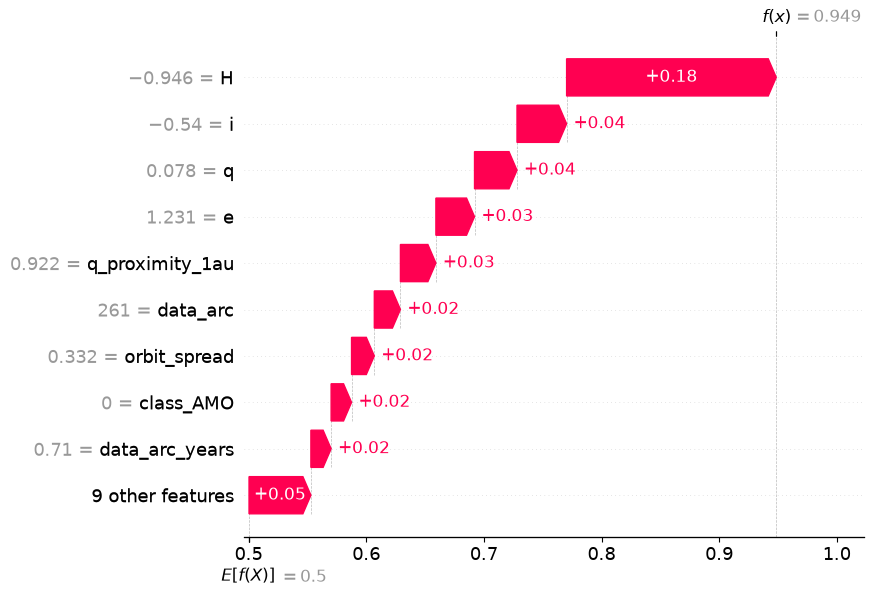


--- False Negative (row 79) ---


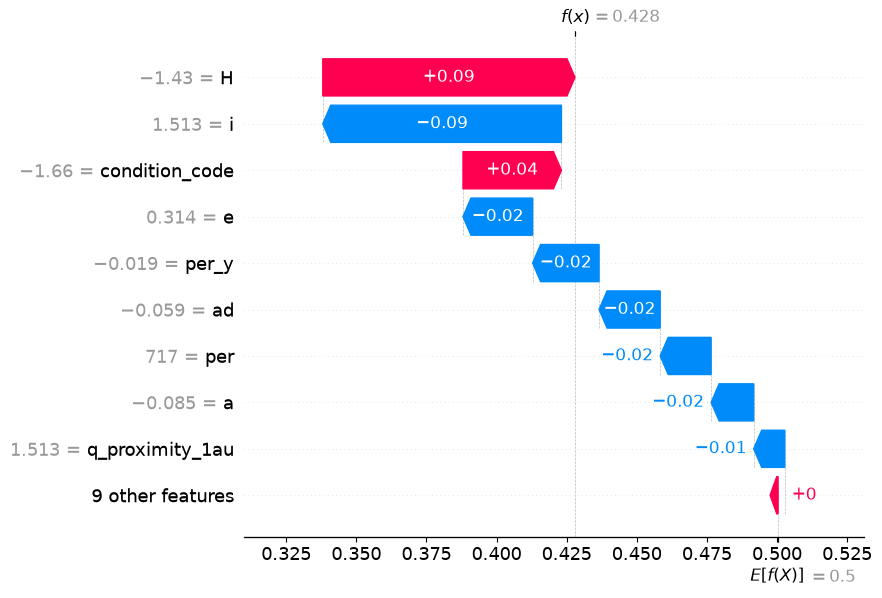

In [ ]:
for label, idx in [("True Positive", tp_idx), ("False Negative", fn_idx)]:
    print(f"\n--- {label} (row {idx}) ---")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_hazard[idx],
            base_values=base_value,
            data=X_test.iloc[idx],
            feature_names=X_test.columns.tolist()
        ),
        show=True
    )

In [ ]:
print(f"""
Final Model Evaluation Summary
--------------------------------
ROC-AUC: {auc_score:.4f}
Total test samples: {len(y_test)}
Hazardous in test set: {y_test.sum()}
See classification_report (Cell 4) for Precision/Recall/F1 per class.
See confusion_matrix.png for the full breakdown.
See shap_summary.png for global feature impact.
""")


Final Model Evaluation Summary
--------------------------------
ROC-AUC: 0.9675
Total test samples: 8256
Hazardous in test set: 508
See classification_report (Cell 4) for Precision/Recall/F1 per class.
See confusion_matrix.png for the full breakdown.
See shap_summary.png for global feature impact.

